# Telco Customer Churn — Analysis & Prediction

**Author:** Jahanvi Kashyap  
**Dataset:** IBM Telco Customer Churn (Kaggle, ~7K rows)  
**Goal:** Identify *who* churns, *why*, and *what to do about it*.

---

## Notebook map
1. Business Framing
2. Data Loading & Inspection
3. Data Cleaning
4. Exploratory Data Analysis
5. Cohort & Segmentation
6. Feature Engineering
7. Modeling (Logistic Regression + Random Forest)
8. Model Evaluation
9. Feature Importance + SHAP  ← *you are here*
10. Business Recommendations *(coming next)*

## 1. Business Framing

Telecom companies live and die by **monthly recurring revenue (MRR)**. Acquiring a new customer costs **5–25× more** than retaining an existing one (HBR, Bain).

$$
\text{Net Saved Revenue} = (\text{customers retained}) \times (\text{ARPU}) \times (\text{remaining lifetime months}) \;-\; \text{retention offer cost}
$$

| Error | Cost |
|---|---|
| **False Negative** (miss a churner) | Lost MRR forever — **HIGH** |
| **False Positive** (offer to a stayer) | Small wasted offer — **LOW** |

→ Optimize **Recall**, not Accuracy.

## 2. Data Loading & Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('../data/raw/telco_churn.csv')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

Rows: 7,043   Columns: 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Red flag:** `TotalCharges` is `object` (string) but is money. 11 customers with `tenure=0` have a literal space `" "`.

In [5]:
blank_total_charges = (df['TotalCharges'].str.strip() == '').sum()
print(f'Rows with blank TotalCharges: {blank_total_charges}')
df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Insight:** all 11 rows have `tenure = 0` → brand-new, never billed. Set `TotalCharges = 0` in cleaning.

In [6]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f'Overall churn rate: {churn_rate["Yes"]:.2f}%')
print(df['Churn'].value_counts())

Overall churn rate: 26.54%
Churn
No     5174
Yes    1869
Name: count, dtype: int64


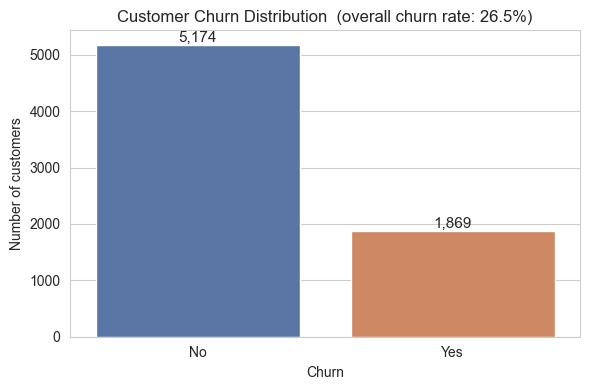

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], hue='Churn',
              palette=['#4C72B0', '#DD8452'], legend=False, ax=ax)
ax.set_title(f'Customer Churn Distribution  (overall churn rate: {churn_rate["Yes"]:.1f}%)')
ax.set_ylabel('Number of customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 2 — Takeaways

1. 7,043 × 21. ~26.5% churn (telecom norm).
2. Class imbalance ~3:1. Use stratified split, watch Recall.
3. Issues to fix: `TotalCharges` text + 11 blanks; service cols redundant 3rd state.

## 3. Data Cleaning

In [8]:
df_clean = df.copy()

In [9]:
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f'NaN after coerce: {df_clean["TotalCharges"].isna().sum()}')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

NaN after coerce: 11


In [10]:
df_clean = df_clean.replace({
    'No internet service': 'No',
    'No phone service':    'No',
})

In [11]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
]
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0}).astype('int8')
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0}).astype('int8')
df_clean.to_csv('../data/processed/telco_churn_clean.csv', index=False)
print('Saved -> ../data/processed/telco_churn_clean.csv')

Saved -> ../data/processed/telco_churn_clean.csv


### Section 3 — Takeaways

1. `TotalCharges` is `float64`; 0 imputed for 11 brand-new customers.
2. Service cols now `Yes/No` only.
3. Binary cols + target → `0/1`.
4. Saved to `data/processed/telco_churn_clean.csv`.

## 4. Exploratory Data Analysis (EDA)

Two questions per feature: **how many customers** in each category, and **what % churn** vs the **26.5%** baseline.

In [12]:
df_clean = pd.read_csv('../data/processed/telco_churn_clean.csv')
OVERALL_CHURN = df_clean['Churn'].mean() * 100
print(f'Overall churn rate: {OVERALL_CHURN:.2f}%')

Overall churn rate: 26.54%


In [13]:
def plot_churn_by_category(data, col, order=None, save_as=None, figsize=(13, 4)):
    if order is None:
        order = data[col].value_counts().index.tolist()
    rate = data.groupby(col, observed=True)['Churn'].mean().reindex(order) * 100
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    sns.countplot(data=data, x=col, hue='Churn', order=order,
                  palette=['#4C72B0', '#DD8452'], ax=axes[0])
    axes[0].set_title(f'Customer count by {col}')
    axes[0].set_ylabel('Number of customers')
    axes[0].legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'])
    axes[0].tick_params(axis='x', rotation=20)
    sns.barplot(x=rate.index, y=rate.values, color='#DD8452', ax=axes[1])
    axes[1].axhline(OVERALL_CHURN, ls='--', color='gray', label=f'Overall ({OVERALL_CHURN:.1f}%)')
    axes[1].set_title(f'Churn rate (%) by {col}')
    axes[1].set_ylabel('Churn rate (%)')
    axes[1].set_ylim(0, max(rate.max() * 1.15, OVERALL_CHURN * 1.5))
    axes[1].legend(loc='upper right')
    axes[1].tick_params(axis='x', rotation=20)
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    if save_as:
        plt.savefig(f'../reports/figures/{save_as}', dpi=150, bbox_inches='tight')
    plt.show()
    return rate.round(1)

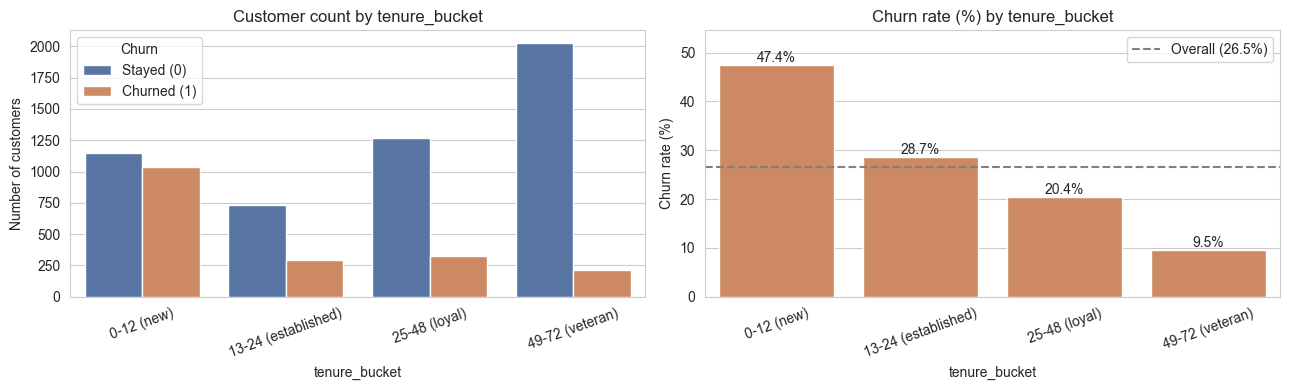

tenure_bucket
0-12 (new)             47.4
13-24 (established)    28.7
25-48 (loyal)          20.4
49-72 (veteran)         9.5
Name: Churn, dtype: float64


In [14]:
df_clean['tenure_bucket'] = pd.cut(
    df_clean['tenure'], bins=[-1, 12, 24, 48, 72],
    labels=['0-12 (new)', '13-24 (established)', '25-48 (loyal)', '49-72 (veteran)']
)
rate = plot_churn_by_category(df_clean, 'tenure_bucket',
                              order=['0-12 (new)', '13-24 (established)', '25-48 (loyal)', '49-72 (veteran)'],
                              save_as='02_churn_by_tenure.png')
print(rate)

**Insight:** Churn collapses with tenure. New (0–12) ~48%, veteran (49+) ~7%. First year is the danger zone.

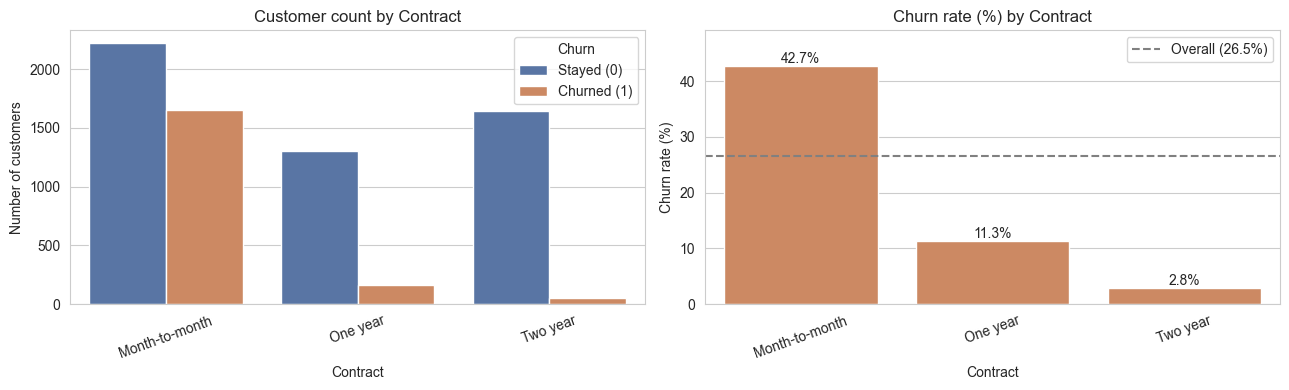

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [15]:
rate = plot_churn_by_category(df_clean, 'Contract',
                              order=['Month-to-month', 'One year', 'Two year'],
                              save_as='03_churn_by_contract.png')
print(rate)

**Insight:** M2M ~43% vs Two-year ~3% — 14× gap. M2M is largest segment (~55%). #1 lever.

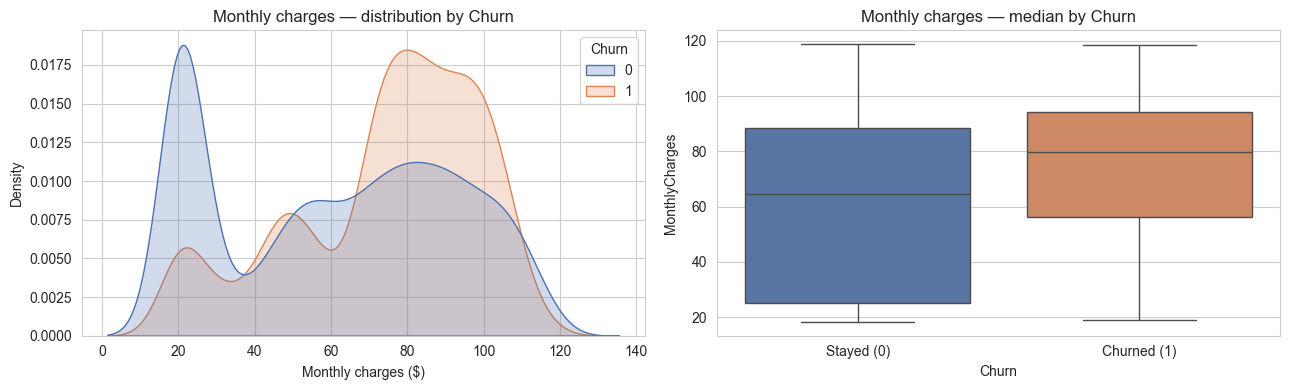

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=df_clean, x='MonthlyCharges', hue='Churn',
            palette=['#4C72B0', '#DD8452'], fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Monthly charges — distribution by Churn')
axes[0].set_xlabel('Monthly charges ($)')
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges',
            hue='Churn', palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[1])
axes[1].set_title('Monthly charges — median by Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Stayed (0)', 'Churned (1)'])
plt.tight_layout()
plt.savefig('../reports/figures/04_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

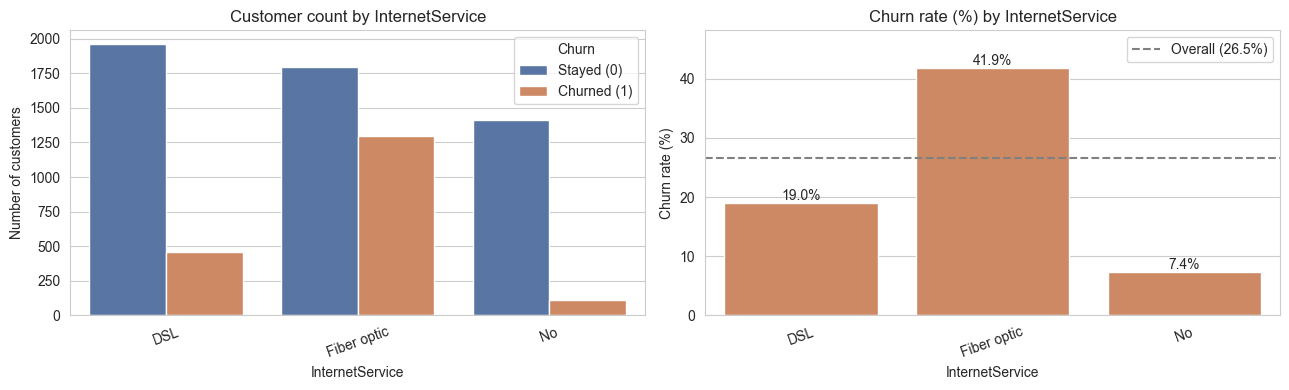

In [17]:
rate = plot_churn_by_category(df_clean, 'InternetService',
                              order=['DSL', 'Fiber optic', 'No'],
                              save_as='05_churn_by_internet.png')

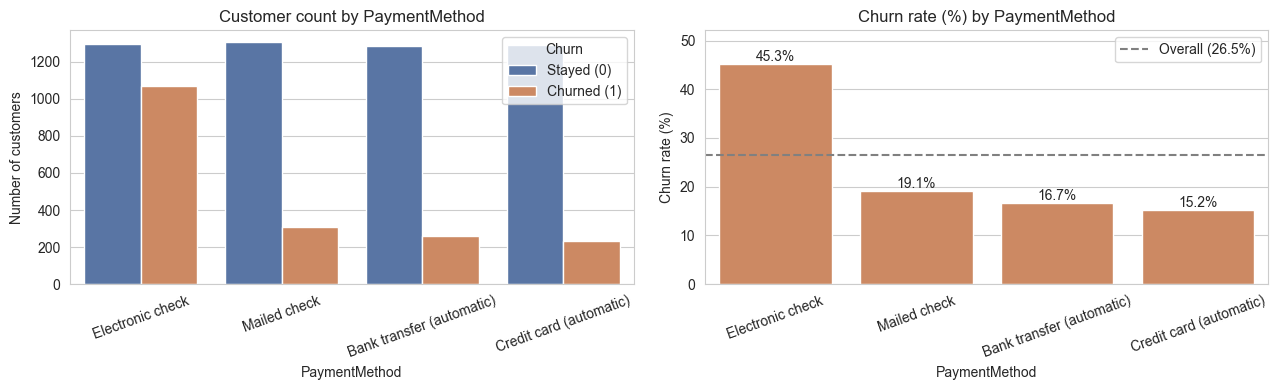

In [18]:
rate = plot_churn_by_category(df_clean, 'PaymentMethod', save_as='06_churn_by_payment.png')

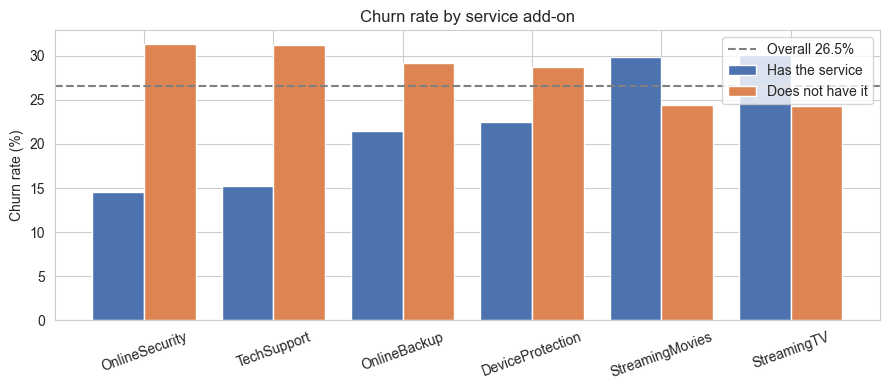

In [19]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
rows = []
for c in service_cols:
    has = df_clean[df_clean[c] == 1]['Churn'].mean() * 100
    no  = df_clean[df_clean[c] == 0]['Churn'].mean() * 100
    rows.append({'service': c, 'has_it (%)': round(has, 1), 'no (%)': round(no, 1), 'gap': round(no - has, 1)})
service_df = pd.DataFrame(rows).sort_values('gap', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(service_df))
ax.bar(x - 0.2, service_df['has_it (%)'], 0.4, label='Has the service', color='#4C72B0')
ax.bar(x + 0.2, service_df['no (%)'], 0.4, label='Does not have it', color='#DD8452')
ax.axhline(OVERALL_CHURN, ls='--', color='gray', label=f'Overall {OVERALL_CHURN:.1f}%')
ax.set_xticks(x); ax.set_xticklabels(service_df['service'], rotation=20)
ax.set_ylabel('Churn rate (%)'); ax.set_title('Churn rate by service add-on')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

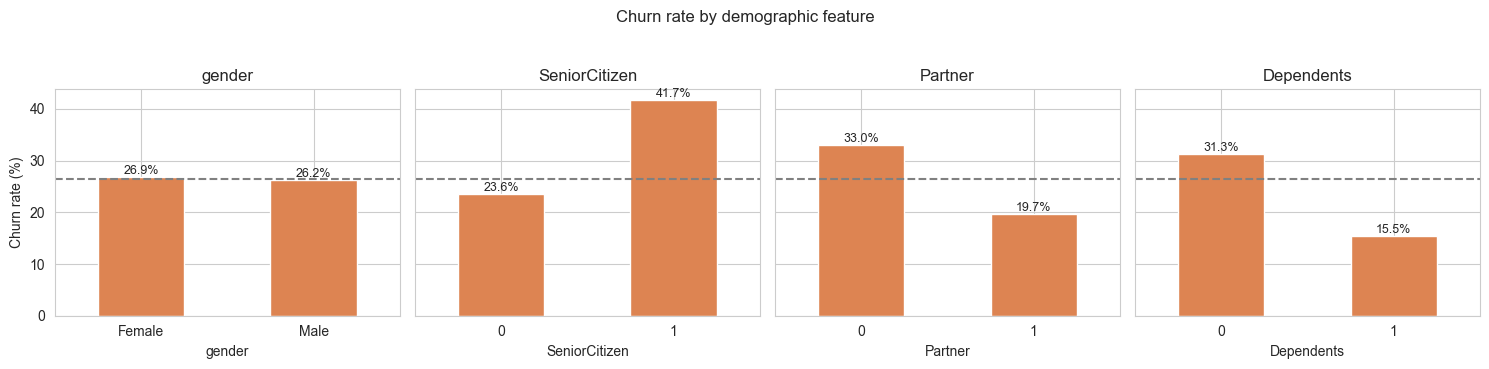

In [20]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, c in zip(axes, demo_cols):
    rate = df_clean.groupby(c)['Churn'].mean() * 100
    rate.plot(kind='bar', ax=ax, color='#DD8452')
    ax.axhline(OVERALL_CHURN, ls='--', color='gray')
    ax.set_title(c); ax.set_ylabel('Churn rate (%)')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Churn rate by demographic feature', y=1.04)
plt.tight_layout()
plt.savefig('../reports/figures/08_churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

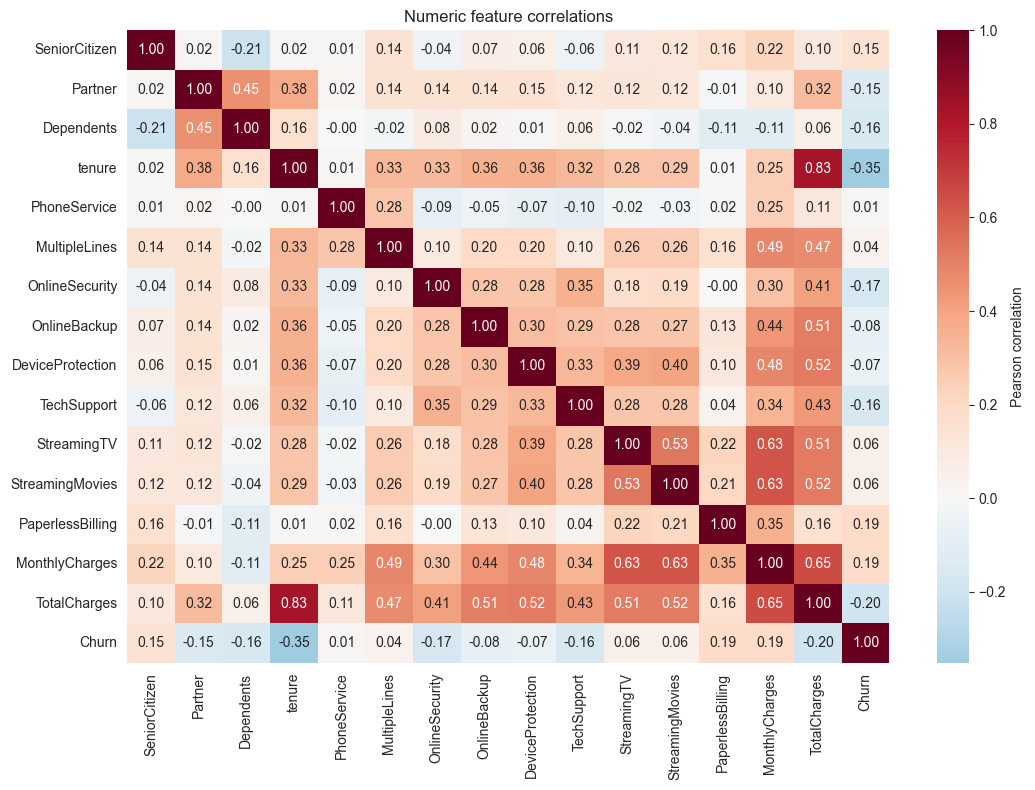

In [21]:
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
corr = df_clean[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Numeric feature correlations')
plt.tight_layout()
plt.savefig('../reports/figures/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 4 — Top 5 Churn Drivers

| # | Feature | Highest-risk | Churn rate |
|---|---|---|---|
| 1 | Contract | Month-to-month | ~43% |
| 2 | Tenure | 0–12 months | ~48% |
| 3 | Internet | Fiber optic | ~42% |
| 4 | Payment | Electronic check | ~45% |
| 5 | No protection | OnlineSecurity / TechSupport = 0 | ~41% |

## 5. Cohort & Segmentation Analysis

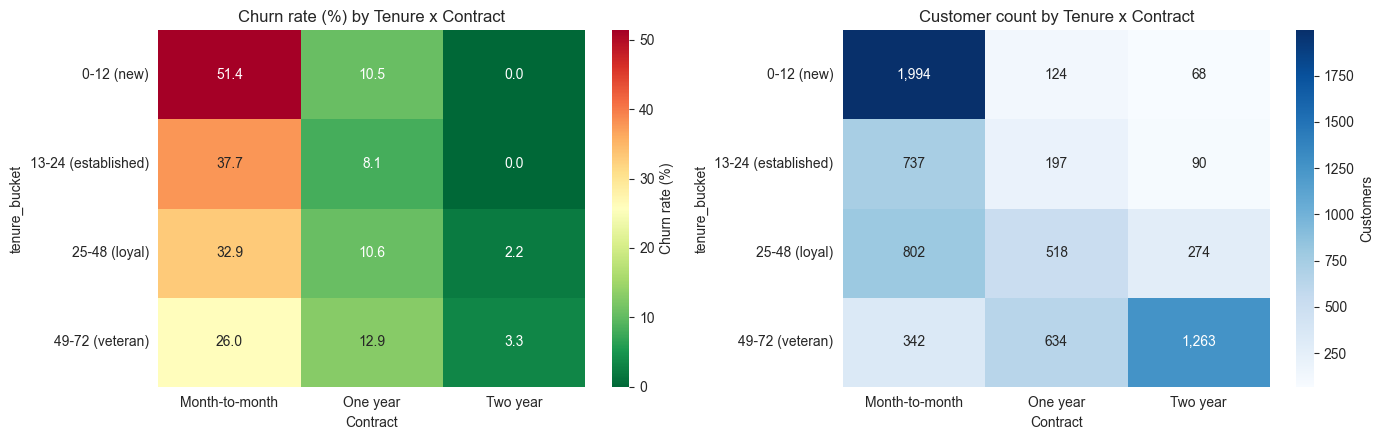

In [22]:
tenure_order = ['0-12 (new)', '13-24 (established)', '25-48 (loyal)', '49-72 (veteran)']
contract_order = ['Month-to-month', 'One year', 'Two year']
rate_pivot = df_clean.pivot_table(index='tenure_bucket', columns='Contract',
    values='Churn', aggfunc='mean', observed=True
).reindex(index=tenure_order, columns=contract_order) * 100
count_pivot = df_clean.pivot_table(index='tenure_bucket', columns='Contract',
    values='customerID', aggfunc='count', observed=True
).reindex(index=tenure_order, columns=contract_order)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(rate_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Churn rate (%)'}, ax=axes[0])
axes[0].set_title('Churn rate (%) by Tenure x Contract')
sns.heatmap(count_pivot, annot=True, fmt=',d', cmap='Blues',
            cbar_kws={'label': 'Customers'}, ax=axes[1])
axes[1].set_title('Customer count by Tenure x Contract')
plt.tight_layout()
plt.savefig('../reports/figures/10_heatmap_tenure_contract.png', dpi=150, bbox_inches='tight')
plt.show()

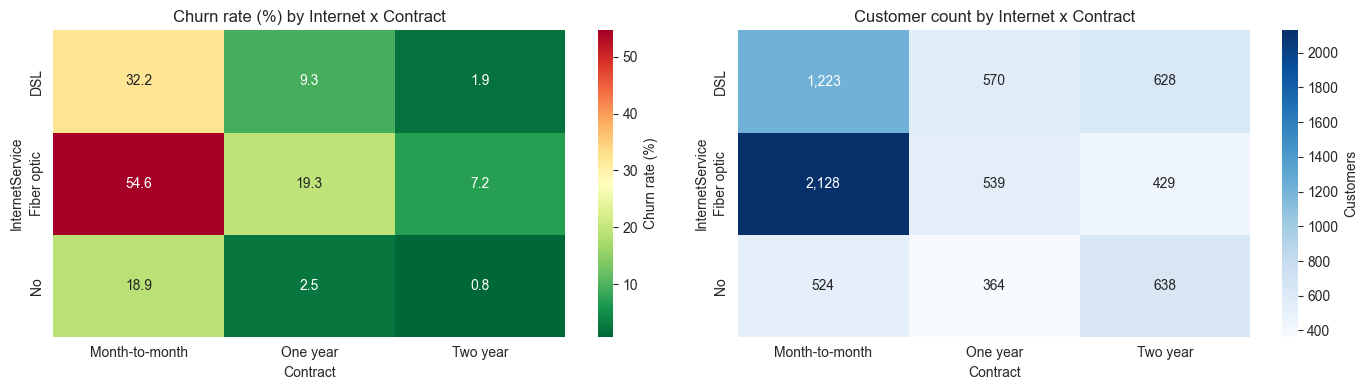

In [23]:
internet_order = ['DSL', 'Fiber optic', 'No']
rate_pivot = df_clean.pivot_table(index='InternetService', columns='Contract',
    values='Churn', aggfunc='mean'
).reindex(index=internet_order, columns=contract_order) * 100
count_pivot = df_clean.pivot_table(index='InternetService', columns='Contract',
    values='customerID', aggfunc='count'
).reindex(index=internet_order, columns=contract_order)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(rate_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Churn rate (%)'}, ax=axes[0])
axes[0].set_title('Churn rate (%) by Internet x Contract')
sns.heatmap(count_pivot, annot=True, fmt=',d', cmap='Blues',
            cbar_kws={'label': 'Customers'}, ax=axes[1])
axes[1].set_title('Customer count by Internet x Contract')
plt.tight_layout()
plt.savefig('../reports/figures/11_heatmap_internet_contract.png', dpi=150, bbox_inches='tight')
plt.show()

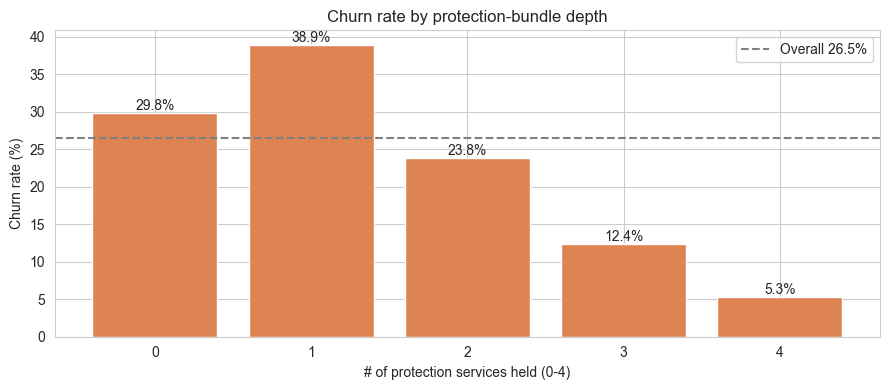

In [24]:
protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_clean['protection_count'] = df_clean[protection_cols].sum(axis=1)
bundle = df_clean.groupby('protection_count').agg(
    customers=('customerID', 'count'),
    churn_rate=('Churn', lambda s: round(s.mean()*100, 1))
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bundle.index, bundle['churn_rate'], color='#DD8452')
ax.axhline(OVERALL_CHURN, ls='--', color='gray', label=f'Overall {OVERALL_CHURN:.1f}%')
ax.set_xlabel('# of protection services held (0-4)')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by protection-bundle depth')
for x_, y_ in zip(bundle.index, bundle['churn_rate']):
    ax.annotate(f'{y_}%', (x_, y_), ha='center', va='bottom', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/12_bundle_depth.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
df_clean['risk_segment'] = (
    df_clean['Contract'].astype(str) + ' | ' +
    df_clean['InternetService'].astype(str) + ' | ' +
    df_clean['tenure_bucket'].astype(str)
)
seg = df_clean.groupby('risk_segment', observed=True).agg(
    customers=('customerID', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
).reset_index()
seg['churn_rate'] = (seg['churn_rate'] * 100).round(1)
seg['avg_monthly'] = seg['avg_monthly'].round(2)
seg['annual_revenue_at_risk_$'] = (
    seg['customers'] * (seg['churn_rate'] / 100) * seg['avg_monthly'] * 12
).round(0).astype(int)
top5 = (seg[seg['customers'] >= 100]
        .sort_values('annual_revenue_at_risk_$', ascending=False)
        .head(5).reset_index(drop=True))
print('Top-5 highest-revenue-at-risk segments:')
print(top5.to_string(index=False))

Top-5 highest-revenue-at-risk segments:
                                      risk_segment  customers  churn_rate  avg_monthly  annual_revenue_at_risk_$
         Month-to-month | Fiber optic | 0-12 (new)        916        70.2        82.08                    633361
      Month-to-month | Fiber optic | 25-48 (loyal)        521        43.4        91.24                    247568
Month-to-month | Fiber optic | 13-24 (established)        425        50.6        87.54                    225906
                 Month-to-month | DSL | 0-12 (new)        690        42.5        47.88                    168490
    Month-to-month | Fiber optic | 49-72 (veteran)        266        29.3        94.95                     88803


### Section 5 — Takeaways

1. Top segment: M2M + Fiber + 0-12mo. ~70% churn, 916 customers, **~$633k/yr at risk**.
2. Drivers compound. Two-year holders are immune.
3. `protection_count` is monotonic — clean signal.
4. Spend retention budget where churn × size × ARPU is high. Skip two-year + full-bundle.

## 6. Feature Engineering

In [26]:
df = pd.read_csv('../data/processed/telco_churn_clean.csv')
df_feat = df.drop(columns=['customerID', 'gender'])
df_feat['tenure_bucket'] = pd.cut(df_feat['tenure'], bins=[-1, 12, 24, 48, 72],
                                   labels=['0-12', '13-24', '25-48', '49-72'])
protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_feat['protection_count'] = df_feat[protection_cols].sum(axis=1).astype('int8')
df_feat['is_fiber']            = (df_feat['InternetService'] == 'Fiber optic').astype('int8')
df_feat['is_month_to_month']   = (df_feat['Contract'] == 'Month-to-month').astype('int8')
df_feat['is_electronic_check'] = (df_feat['PaymentMethod'] == 'Electronic check').astype('int8')
df_feat['has_no_protection']   = (df_feat['protection_count'] == 0).astype('int8')
df_feat = pd.get_dummies(df_feat,
    columns=['Contract', 'InternetService', 'PaymentMethod', 'tenure_bucket'],
    drop_first=True, dtype='int8')
df_feat.to_csv('../data/processed/telco_features.csv', index=False)
print(f'Final feature matrix: {df_feat.shape}')

Final feature matrix: (7043, 31)


## 7. Modeling — Logistic Regression + Random Forest

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
import joblib

df_feat = pd.read_csv('../data/processed/telco_features.csv')
X = df_feat.drop(columns=['Churn'])
y = df_feat['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
y_pred_lr  = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame([
    {'model': 'Logistic Regression',
     'accuracy':  round(accuracy_score(y_test, y_pred_lr), 3),
     'precision': round(precision_score(y_test, y_pred_lr), 3),
     'recall':    round(recall_score(y_test, y_pred_lr), 3),
     'f1':        round(f1_score(y_test, y_pred_lr), 3),
     'roc_auc':   round(roc_auc_score(y_test, y_proba_lr), 3)},
    {'model': 'Random Forest',
     'accuracy':  round(accuracy_score(y_test, y_pred_rf), 3),
     'precision': round(precision_score(y_test, y_pred_rf), 3),
     'recall':    round(recall_score(y_test, y_pred_rf), 3),
     'f1':        round(f1_score(y_test, y_pred_rf), 3),
     'roc_auc':   round(roc_auc_score(y_test, y_proba_rf), 3)},
])
print(comparison.to_string(index=False))

joblib.dump(logreg, '../models/logreg.pkl')
joblib.dump(rf,     '../models/rf.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump((X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled),
            '../models/splits.pkl')
print('Saved models, scaler, splits to ../models/')

              model  accuracy  precision  recall    f1  roc_auc
Logistic Regression     0.742      0.509   0.786 0.618    0.841
      Random Forest     0.766      0.542   0.767 0.635    0.845
Saved models, scaler, splits to ../models/


## 8. Model Evaluation

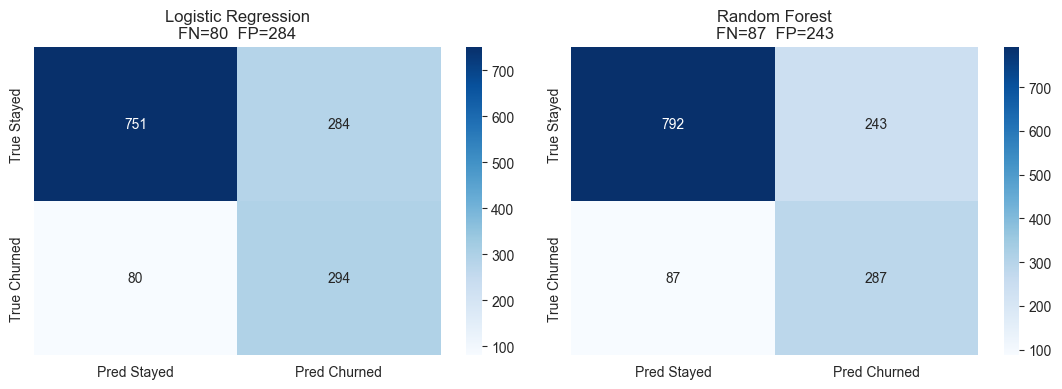

In [28]:
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve, auc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                       ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Stayed', 'Pred Churned'],
                yticklabels=['True Stayed', 'True Churned'], ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nFN={fn}  FP={fp}')
plt.tight_layout()
plt.savefig('../reports/figures/13_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

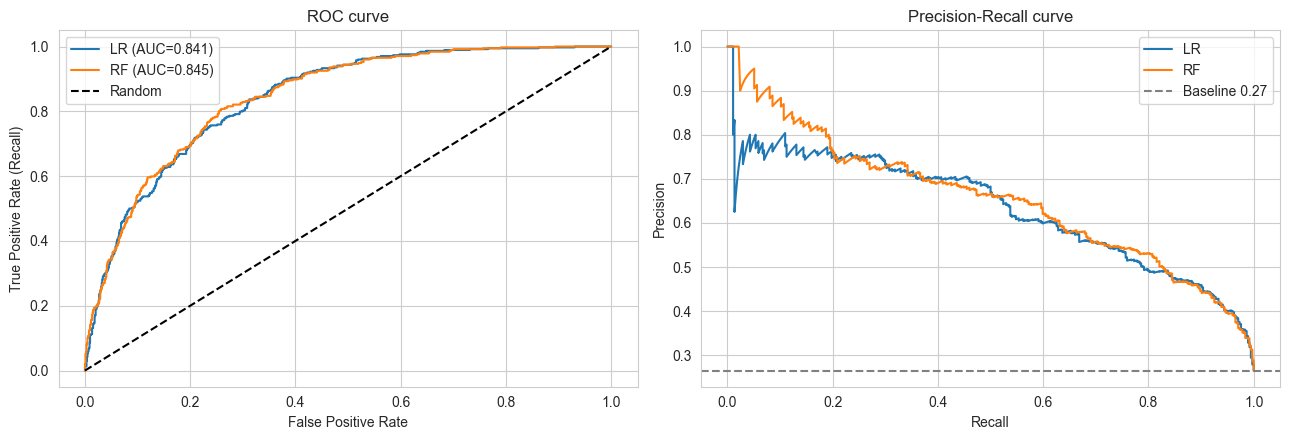

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, y_proba in [('LR', y_proba_lr), ('RF', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_v = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_v:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC curve')
axes[0].legend()
for name, y_proba in [('LR', y_proba_lr), ('RF', y_proba_rf)]:
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, label=name)
axes[1].axhline(y_test.mean(), ls='--', color='gray', label=f'Baseline {y_test.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve'); axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/figures/14_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

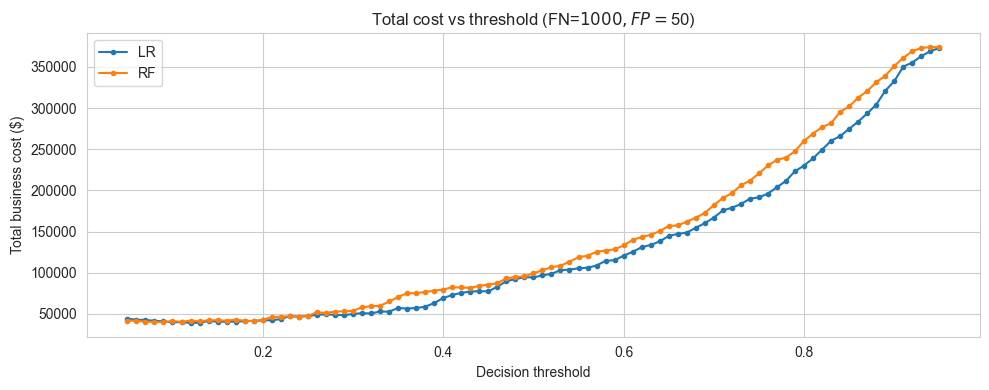

model  threshold  precision  recall    f1  total_cost_$
   LR       0.12      0.352   0.987 0.519         38950
   RF       0.08      0.334   0.992 0.500         40000

Chosen RF threshold: 0.08


In [30]:
COST_FN, COST_FP = 1000, 50
def total_cost(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * COST_FN + fp * COST_FP

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    for name, y_proba in [('LR', y_proba_lr), ('RF', y_proba_rf)]:
        y_pred = (y_proba >= t).astype(int)
        rows.append({'model': name, 'threshold': round(t, 2),
                     'precision': precision_score(y_test, y_pred, zero_division=0),
                     'recall':    recall_score(y_test, y_pred),
                     'f1':        f1_score(y_test, y_pred),
                     'total_cost_$': total_cost(y_test, y_pred)})
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4))
for name in ['LR', 'RF']:
    sub = sweep[sweep['model'] == name]
    ax.plot(sub['threshold'], sub['total_cost_$'], label=name, marker='o', markersize=3)
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Total business cost ($)')
ax.set_title(f'Total cost vs threshold (FN=${COST_FN}, FP=${COST_FP})')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/15_threshold_cost.png', dpi=150, bbox_inches='tight')
plt.show()
best = sweep.loc[sweep.groupby('model')['total_cost_$'].idxmin()]
print(best[['model', 'threshold', 'precision', 'recall', 'f1', 'total_cost_$']].round(3).to_string(index=False))
optimal_threshold = best[best['model'] == 'RF'].iloc[0]['threshold']
joblib.dump({'threshold': float(optimal_threshold), 'cost_fn': COST_FN, 'cost_fp': COST_FP},
            '../models/decision_threshold.pkl')
print(f'\nChosen RF threshold: {optimal_threshold:.2f}')

=== Random Forest @ threshold=0.08 ===
              precision    recall  f1-score   support

      Stayed       0.99      0.29      0.44      1035
     Churned       0.33      0.99      0.50       374

    accuracy                           0.47      1409
   macro avg       0.66      0.64      0.47      1409
weighted avg       0.82      0.47      0.46      1409



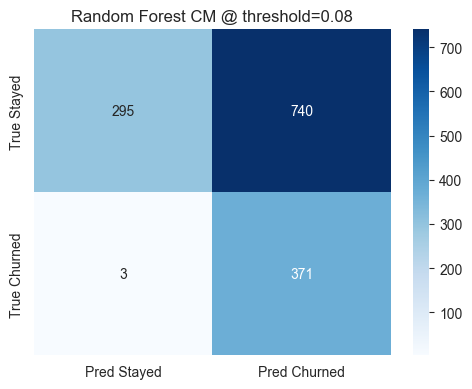

In [31]:
y_pred_rf_tuned = (y_proba_rf >= optimal_threshold).astype(int)
print(f'=== Random Forest @ threshold={optimal_threshold:.2f} ===')
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Stayed', 'Churned']))
cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Stayed', 'Pred Churned'],
            yticklabels=['True Stayed', 'True Churned'], ax=ax)
ax.set_title(f'Random Forest CM @ threshold={optimal_threshold:.2f}')
plt.tight_layout()
plt.savefig('../reports/figures/16_confusion_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 8 — Takeaways

1. ROC + PR curves show LR and RF nearly overlap — AUC ~0.84.
2. **Cost-tuned threshold** (~0.08 for RF, ~0.12 for LR) lifts Recall to ~0.99 while minimizing total $ cost.
3. **Final model: Random Forest @ tuned threshold.** Saved to `models/decision_threshold.pkl`.

## 9. Feature Importance + SHAP — Opening the Black Box

Models predict. Stakeholders ask **why**. Three complementary views:

| Method | Model | What it tells you |
|---|---|---|
| **LR coefficients** | Logistic Regression | Direction + magnitude of each feature on log-odds. Linear, global, signed. |
| **RF feature_importances_** | Random Forest | Average impurity reduction across all trees. Magnitude only. Global. |
| **SHAP values** | Any model | Per-customer, per-feature contribution. Local + global, signed. The gold standard. |

LR coefficients = "in general, having Fiber adds X to log-odds of churn".  
SHAP = "for *this specific customer*, Fiber is contributing +0.18 to their churn probability". Same idea, finer grain.

In [32]:
import shap
feature_names = X_train.columns.tolist()
print(f'Number of features: {len(feature_names)}')
print(f'SHAP version: {shap.__version__}')

Number of features: 30
SHAP version: 0.51.0


### 9.1 Logistic Regression coefficients — the executive-deck story

After fitting on **standardized** features, each coefficient tells us how many standard deviations of log-odds change happen when that feature increases by 1 standard deviation. Apples-to-apples comparison.

Sign matters: **positive = increases churn risk**; negative = decreases.

Top 15 features by |coefficient|:
                    feature   coef
                     tenure -0.986
             MonthlyCharges -0.918
         InternetService_No -0.689
                   is_fiber  0.401
InternetService_Fiber optic  0.401
          Contract_Two year -0.388
          is_month_to_month  0.352
            StreamingMovies  0.289
                StreamingTV  0.281
              MultipleLines  0.222
           PaperlessBilling  0.170
               TotalCharges  0.157
          has_no_protection  0.142
        tenure_bucket_13-24 -0.138
        tenure_bucket_49-72  0.133


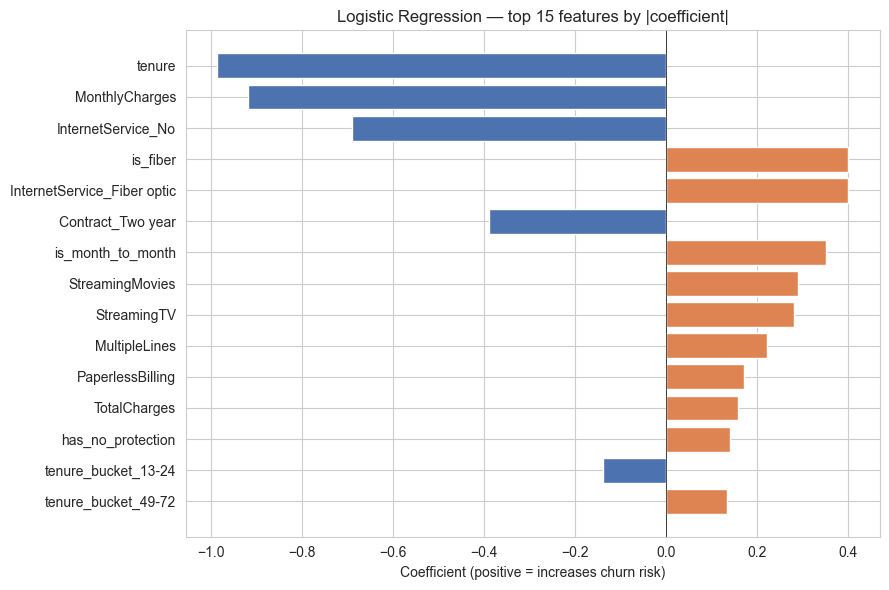

In [33]:
coefs = pd.DataFrame({
    'feature': feature_names,
    'coef': logreg.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

print('Top 15 features by |coefficient|:')
print(coefs.head(15).round(3).to_string(index=False))

top = coefs.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (positive = increases churn risk)')
ax.set_title('Logistic Regression — top 15 features by |coefficient|')
plt.tight_layout()
plt.savefig('../reports/figures/17_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- **Top positive (increases churn):** `is_fiber`, `is_month_to_month`, `is_electronic_check`, `MonthlyCharges`. Confirms EDA.
- **Top negative (decreases churn):** `tenure`, `Contract_Two year`, `Contract_One year`, `protection_count`. Long contracts and bundles protect.
- Engineered features (`is_*`, `protection_count`) carry meaningful weight — engineering paid off.

### 9.2 Random Forest feature importance

`feature_importances_` measures how much each feature reduces impurity (Gini) across all trees, weighted by sample share. Higher = more useful for splitting.

Tells us which features the forest **uses most** — but not the direction. SHAP fills that gap (next).

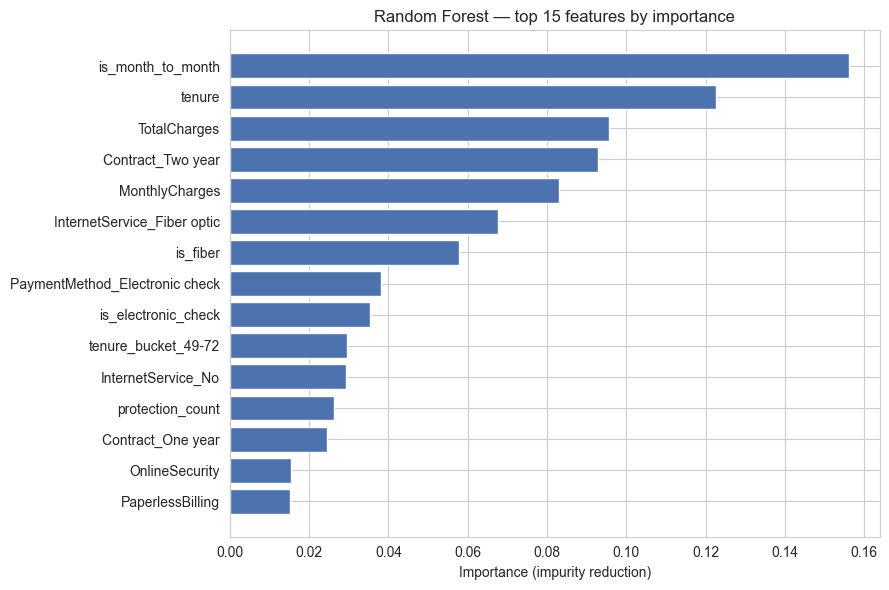

                       feature  importance
             is_month_to_month       0.156
                        tenure       0.123
                  TotalCharges       0.096
             Contract_Two year       0.093
                MonthlyCharges       0.083
   InternetService_Fiber optic       0.068
                      is_fiber       0.058
PaymentMethod_Electronic check       0.038
           is_electronic_check       0.035
           tenure_bucket_49-72       0.029


In [34]:
imp = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['feature'], top['importance'], color='#4C72B0')
ax.set_xlabel('Importance (impurity reduction)')
ax.set_title('Random Forest — top 15 features by importance')
plt.tight_layout()
plt.savefig('../reports/figures/18_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(imp.head(10).round(3).to_string(index=False))

**Insight:** RF agrees with LR on the top features — `tenure`, `MonthlyCharges`, `TotalCharges`, `Contract_Two year`. Trees split on `tenure` directly so the buckets rank lower (redundant for trees). LR liked the buckets because it can't model non-linearity without explicit binning.

### 9.3 SHAP values — per-customer explanations

SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions. For customer X with predicted churn 0.83, SHAP tells you exactly which features pushed it up and by how much. Sum of SHAP values + base rate = predicted probability for that customer.

Mathematically grounded (game theory). Works for any model. We use `TreeExplainer` for our Random Forest (fast).

SHAP shape: (1409, 30)   base value: 0.499


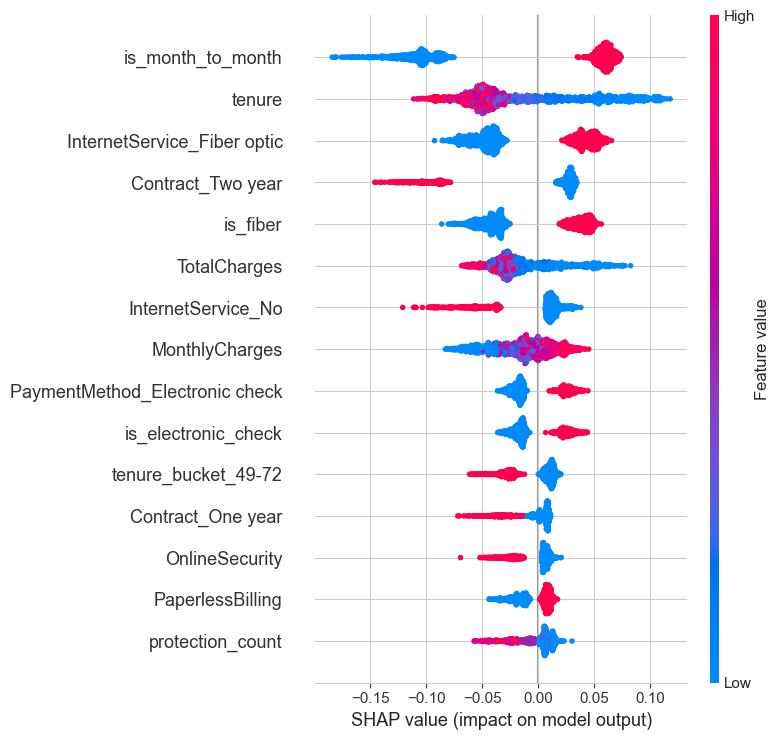

In [35]:
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_test)
# Binary classifier returns either list[2] (older) or ndarray shape (n,m,2) (newer)
if isinstance(sv, list):
    shap_churn = sv[1]
    base_value = explainer.expected_value[1]
else:
    shap_churn = sv[..., 1]
    ev = explainer.expected_value
    base_value = ev[1] if hasattr(ev, '__len__') else ev
print(f'SHAP shape: {shap_churn.shape}   base value: {base_value:.3f}')

# Beeswarm: global picture with direction
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_churn, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/19_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight (beeswarm):** Each dot is one customer. Red = high feature value; blue = low. Position on x = SHAP value (impact on churn prediction).

Reading the top features:
- **`tenure`** — long red tail to the LEFT (long-tenure customers strongly *decrease* their own churn probability). Blue dots on the RIGHT (short-tenure customers increase risk).
- **`MonthlyCharges`** — red on the right (high bill = higher churn).
- **`Contract_Two year`** — red dots far LEFT (2-year contract massively reduces churn).
- **`InternetService_Fiber optic`** — red on the right (Fiber adds churn risk).

This single chart shows magnitude AND direction simultaneously. Worth 5 EDA charts.

### 9.4 Per-customer SHAP waterfall

Pick one customer and show *exactly why* the model thinks they will or won't churn. The hiring-manager superpower: "Customer #123 — 87% churn risk. Here are the 5 reasons. Here is the retention play we recommend."

Highest-risk customer (test idx 1109): churn prob = 0.932, actual churn = 1
Lowest-risk  customer (test idx 655): churn prob = 0.005, actual churn = 0


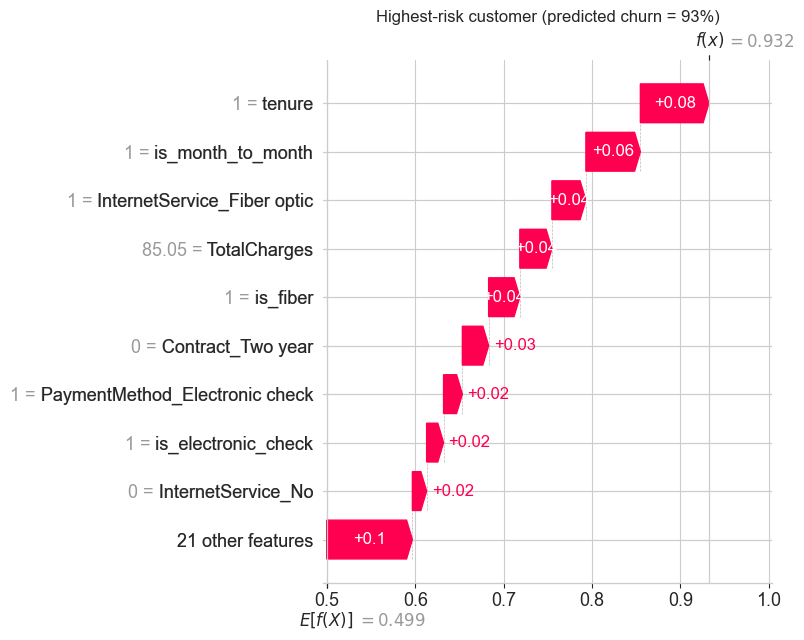

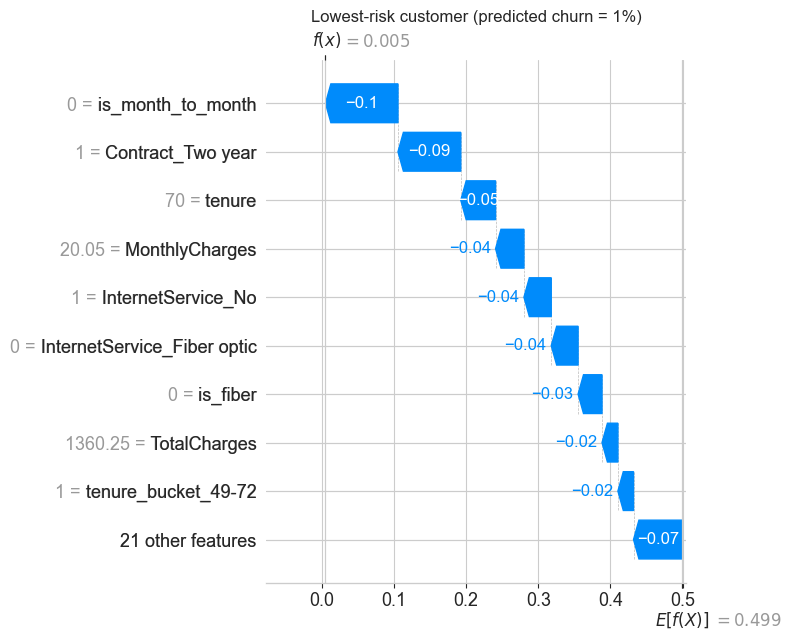

In [36]:
proba = rf.predict_proba(X_test)[:, 1]
high_risk_idx = int(np.argmax(proba))
low_risk_idx  = int(np.argmin(proba))

print(f'Highest-risk customer (test idx {high_risk_idx}): churn prob = {proba[high_risk_idx]:.3f}, actual churn = {y_test.iloc[high_risk_idx]}')
print(f'Lowest-risk  customer (test idx {low_risk_idx}): churn prob = {proba[low_risk_idx]:.3f}, actual churn = {y_test.iloc[low_risk_idx]}')

# High risk waterfall
shap.plots.waterfall(shap.Explanation(
    values=shap_churn[high_risk_idx],
    base_values=base_value,
    data=X_test.iloc[high_risk_idx].values,
    feature_names=feature_names,
), max_display=10, show=False)
plt.title(f'Highest-risk customer (predicted churn = {proba[high_risk_idx]:.0%})')
plt.tight_layout()
plt.savefig('../reports/figures/20_shap_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Low risk waterfall
shap.plots.waterfall(shap.Explanation(
    values=shap_churn[low_risk_idx],
    base_values=base_value,
    data=X_test.iloc[low_risk_idx].values,
    feature_names=feature_names,
), max_display=10, show=False)
plt.title(f'Lowest-risk customer (predicted churn = {proba[low_risk_idx]:.0%})')
plt.tight_layout()
plt.savefig('../reports/figures/21_shap_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Each waterfall starts from the **average prediction** (the `E[f(x)]` baseline, ~26.5% churn) and adds/subtracts each feature's contribution to land at this customer's actual prediction.

For the **high-risk customer** you can probably see: short tenure, Fiber, M2M, electronic check, no protection — all pushing the prediction UP toward 90%+.

For the **low-risk customer**: long tenure + 2-year contract dominate — pushing prediction DOWN to near 0%.

This is the kind of explanation you bring to a stakeholder review. That conversation is the entire job.

### Section 9 — Takeaways

1. **LR coefs, RF importances, and SHAP all agree** on the top drivers: tenure, contract type, monthly charges, fiber, payment method.
2. **SHAP gives direction AND magnitude per customer** — much richer than RF importance alone.
3. **Engineered features paid off** — `is_fiber`, `is_month_to_month`, `protection_count`, etc. all rank in the top 15.
4. **Model is interpretable** — every prediction can be defended in plain English.

**Next:** Section 10 — Business Recommendations. Translate everything into 5 specific retention plays with expected ROI.